In [1]:
import jax
import jax.numpy as jnp
from DON import *
import optax
import matplotlib.pyplot as plt
import src.util.functions as functions
import pybamm
import numpy as np
from tqdm import trange

In [2]:
# Set random keys
main_key = jax.random.PRNGKey(0)
key_train, key_test = jax.random.split(main_key)

params_bat = pybamm.ParameterValues("Chen2020")

# Hyperparameters
num_train = 2000
num_test = 200
batch_size = 32
learning_rate = 1e-4
num_epochs = 50

C = params_bat["Nominal cell capacity [A.h]"]    # example scalar for GaussianRFCurrent
t_max = 3600
num_samples_I = 75
num_samples_c0 = 20
K = num_samples_I * num_samples_c0
t = np.linspace(0, t_max, num_samples_I)
r = np.linspace(0, 1, num_samples_c0)

In [3]:
spm = pybamm.lithium_ion.SPM()
Ran = params_bat["Negative particle radius [m]"]
Rca = params_bat["Positive particle radius [m]"]

def get_targets(I_samples, soc=0.5):
    set_targets_anode = []
    set_targets_cathode = []
    set_c0_anode = []
    set_c0_cathode = []
    for I_func in I_samples:
        sim = pybamm.Simulation(spm, parameter_values=params_bat)
        sim.events = []
        params_bat["Current function [A]"] = pybamm.Interpolant(t, -1.* I_func, pybamm.t)
        sol = sim.solve(initial_soc=soc, t_eval=t)
        c0_anode = sol["Negative particle concentration"].entries[:,0,0]
        c0_cathode = sol["Positive particle concentration"].entries[:,0,0]
        cn_target_anode = sol["Negative particle concentration"].entries[:,0,:]#(t=t, r=r*Ran, x=0)
        cn_target_cathode = sol["Positive particle concentration"].entries[:,0,:]#(t=t, r=r*Ran, x=0)
        
        set_targets_anode.append(cn_target_anode)
        set_targets_cathode.append(cn_target_cathode)
        set_c0_anode.append(c0_anode)
        set_c0_cathode.append(c0_cathode)

    return set_targets_anode, set_c0_anode, set_targets_cathode, set_c0_cathode,

def generate_training_data(key_train):
    train_keys = jax.random.split(key_train, num_train)
    train_I = []
    for k in train_keys:
        # Generate a random current function
        I_func = functions.GaussianRFCurrent(k, C, t_max)
        train_I.append(I_func(t))
    return train_I

def generate_data(key, num_samples):
    keys = jax.random.split(key, num_samples)
    set_I = []
    for k in keys:
        # Generate a random current function
        I_func = functions.GaussianRFCurrent(k, C, t_max)
        set_I.append(I_func(t))
    return set_I

In [4]:
family = "GRF"
id  = "8"
path = "data/spm/DON/"
train_data = np.load(path + "train/" + family + ".npz")
test_data = np.load(path + "test/" + family + ".npz")

train_I = np.array(train_data["current"])
test_I = np.array(test_data["current"])

train_cn = np.array(train_data["target_concentration_anode"])
test_cn = np.array(test_data["target_concentration_anode"])

train_c0 = np.array(train_data["initial_concentration_anode"])
test_c0 = np.array(test_data["initial_concentration_anode"])


cpu = jax.devices("cpu")[0]
gpu = jax.devices("gpu")[0]  # Should be the GPU

In [5]:
# train_I = jnp.array(generate_data(key_train, num_train))
# test_I = jnp.array(generate_data(key_test, num_test))
# train_cn_anode, train_c0_anode, train_cn_cathode, train_c0_cathode = get_targets(train_I)
# test_cn_anode, test_c0_anode, test_cn_cathode, test_c0_cathode = get_targets(test_I)
# train_cn_anode = jnp.array(train_cn_anode)
# test_cn_anode = jnp.array(test_cn_anode)
# train_c0_anode = jnp.array(train_c0_anode)
# test_c0_anode = jnp.array(test_c0_anode)

# train_cn_cathode = jnp.array(train_cn_cathode)
# test_cn_cathode = jnp.array(test_cn_cathode)
# train_c0_cathode = jnp.array(train_c0_cathode)
# test_c0_cathode = jnp.array(test_c0_cathode)

In [6]:
seen = set()
duplicates_found = False

for i in range(num_train):
    # Extract the i-th dataset from the batch
    dataset = train_I[i]

    # Convert to a NumPy array and then to bytes for hashing
    dataset_hash = hash(np.array(dataset).tobytes())

    if dataset_hash in seen:
        print(f"Duplicate dataset found at index {i}.")
        duplicates_found = True
        break
    else:
        seen.add(dataset_hash)

if not duplicates_found:
    print("No duplicates found among the 2000 samples in the batch.")

No duplicates found among the 2000 samples in the batch.


In [7]:
def generate_trunk_points(r_vals, t_vals):
    # By passing r_vals first and using indexing='ij', 
    # R_grid will correspond to radius and T_grid to time.
    # R_grid.shape = (len(r_vals), len(t_vals))
    # T_grid.shape = (len(r_vals), len(t_vals))
    # This means the first dimension is radius and the second is time, 
    # matching how train_cn is indexed (r, t).
    R_grid, T_grid = jnp.meshgrid(r_vals, t_vals, indexing='ij')
    
    # Flatten into K x 2, preserving the (r, t) ordering in the flattening:
    # The resulting points will be in an order consistent with flattening (r, t) arrays.
    trunk_points = jnp.stack([T_grid.flatten(), R_grid.flatten()], axis=-1)
    return trunk_points


In [8]:
trunk_points = generate_trunk_points(r, t/t_max)

In [9]:
def data_loader(train_I, train_c0, train_cn, trunk_points, batch_size):
    """
    A simple data loader generator that yields batches of training data.
    
    Parameters
    ----------
    train_I : np.ndarray or jnp.ndarray
        Current samples array of shape (num_train, 75).
    train_c0 : np.ndarray or jnp.ndarray
        Initial concentration array of shape (num_train, 20).
    train_cn : np.ndarray or jnp.ndarray
        Target concentrations array of shape (num_train, 20, 75).
    trunk_points : np.ndarray or jnp.ndarray
        Fixed trunk points array of shape (20*75, 2), or generally (r_len*t_len, 2).
    batch_size : int
        Number of samples per batch.

    Yields
    ------
    (I_batch, c0_batch, trunk_points, cn_batch) : tuple of jnp.ndarray
        I_batch : (batch_size, 75)
        c0_batch : (batch_size, 20)
        trunk_points : (1500, 2) - same for every batch
        cn_batch : (batch_size, 20, 75)
    """
    num_samples = train_I.shape[0]

    # # Convert to jnp if not already
    # train_I = jnp.array(train_I)
    # train_c0 = jnp.array(train_c0)
    # train_cn = jnp.array(train_cn)
    # trunk_points = jnp.array(trunk_points)

    # Shuffle indices
    permutation = np.random.permutation(num_samples)

    for start_idx in range(0, num_samples, batch_size):
        batch_indices = permutation[start_idx:start_idx+batch_size]

        I_batch = train_I[batch_indices]       # (batch_size, 75)
        c0_batch = train_c0[batch_indices]     # (batch_size, 20)
        cn_batch = train_cn[batch_indices]     # (batch_size, 20, 75)
        
        # trunk_points are the same for each batch
        yield I_batch, c0_batch, trunk_points, cn_batch

In [10]:
import jax
import jax.numpy as jnp
from DON import *

width = 500
depth = 11
amount_basis = 64

# Setup model hyperparameters
branch_layers = [width] * depth + [amount_basis]  # M = 200 at the end
trunk_layers = branch_layers

num_samples_I = 75
num_samples_c0 = 20

model = DeepONet(branch_layers=branch_layers, trunk_layers=trunk_layers)

# Create dummy inputs
key1, key2 = jax.random.split(jax.random.PRNGKey(0))
dummy_I = jax.random.normal(key1, (num_samples_I,))
dummy_c0 = jax.random.normal(key1, (num_samples_c0,))      # 75 current samples + 10 initial conditions
dummy_trunk_input = jax.random.normal(key2, (num_samples_I*num_samples_c0, 2))   # K=750 points in the (t,r)-space

# Initialize parameters
params = model.init(jax.random.PRNGKey(42), dummy_I, dummy_c0, dummy_trunk_input)

# Forward pass
output = model.apply(params, dummy_I, dummy_c0, dummy_trunk_input)

print("Output shape:", output.shape)  # should be (750,)
#print("Example output value:", output[0])


Output shape: (1500,)


In [11]:
def single_forward(params, I_single, c0_single, trunk_points):
    # params: model parameters
    # I_single: (85,)
    # c0_single: (20,)
    # trunk_points: (K, 2)
    return model.apply(params, I_single, c0_single, trunk_points)

batch_forward = jax.vmap(
    single_forward,
    in_axes=(None, 0, 0, None),  # params and trunk_points have no batch axis
    out_axes=0
)

def relative_l2_loss(pred, target):
    # pred and target: (K,) arrays
    norm_target = jnp.linalg.norm(target, 2)
    norm_diff = jnp.linalg.norm(pred - target, 2)
    # Handle the case when target is all zeros
    norm_target = jnp.where(norm_target == 0, 1e-12, norm_target)
    return norm_diff / norm_target

def loss_fn(params, I_batch, c0_batch, trunk_pts, cn_batch):
    # pred: (batch, K)
    pred = batch_forward(params, I_batch, c0_batch, trunk_pts)
    # Apply single_sample_loss to each (pred[i], cn_batch[i]) pair
    per_example_loss = jax.vmap(relative_l2_loss, in_axes=(0, 0), out_axes=0)(pred, cn_batch)
    return jnp.mean(per_example_loss)

In [12]:
# Set up the optimizer
learning_rate = 1e-4
optimizer = optax.adam(learning_rate)

opt_state = optimizer.init(params)


# # Set up the training state
# state = train_state.TrainState.create(
#     apply_fn=model.apply,
#     params=params,
#     tx=optimizer
# )

In [13]:
@jax.jit
def train_step(params, opt_state, I_batch, c0_batch, trunk_pts, cn_batch):
    targets_flat = cn_batch.reshape(cn_batch.shape[0], -1)

    def loss_closure(p):
        return loss_fn(p, I_batch, c0_batch, trunk_pts, targets_flat)
    
    # Compute loss and grads
    loss_value, grads = jax.value_and_grad(loss_closure)(params)
    
    # Update parameters
    updates, opt_state = optimizer.update(grads, opt_state)
    params = optax.apply_updates(params, updates)
    
    return params, opt_state, loss_value

In [14]:
train_losses = []
test_losses = []

pbar = trange(num_epochs, desc="Training")

for epoch in pbar:

    # Training phase
    total_train_loss = 0.0
    count = 0

    for I_batch, c0_batch, trunk_pts, cn_batch in data_loader(train_I, train_c0, train_cn, trunk_points, batch_size):
        # targets_flat = cn_batch.reshape(cn_batch.shape[0], -1)
        # loss_value, grads = jax.value_and_grad(loss_fn)(params, I_batch, c0_batch, trunk_pts, targets_flat)
        # updates, opt_state = optimizer.update(grads, opt_state)
        # params = optax.apply_updates(params, updates)

        params, opt_state, loss_value = train_step(params, opt_state, I_batch, c0_batch, trunk_pts, cn_batch)
        
        total_train_loss += loss_value * I_batch.shape[0]
        count += I_batch.shape[0]

    avg_train_loss = total_train_loss / count
    train_losses.append(avg_train_loss)

    # Evaluation on test set after each epoch
    test_targets_flat = test_cn.reshape(test_cn.shape[0], -1)
    test_loss = loss_fn(params, test_I, test_c0, trunk_points, test_targets_flat)
    test_losses.append(test_loss)

    desc_str = f"Epoch {epoch+1}/{num_epochs} | Train Loss: {avg_train_loss:.4f} | Test Loss: {test_loss:.4f}"
    pbar.set_description_str(desc_str)


Training:   0%|          | 0/50 [00:05<?, ?it/s]


KeyboardInterrupt: 

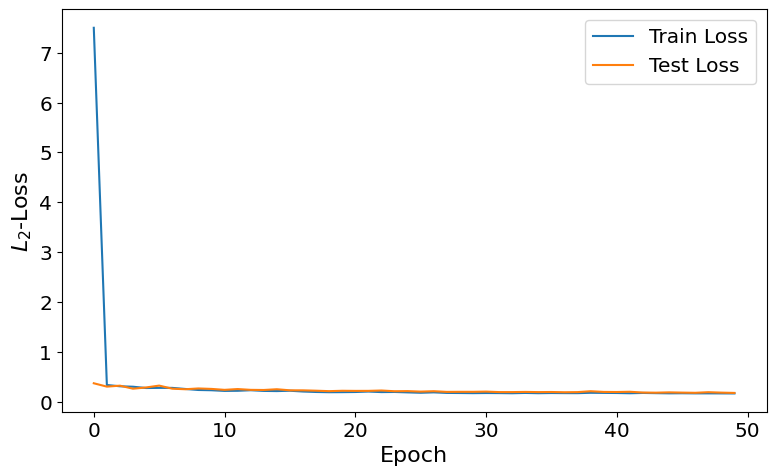

In [ ]:
# Set global font sizes
plt.rcParams.update({
    'font.size': 14.5,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 14.5,
    'ytick.labelsize': 14.5,
    'legend.fontsize': 14.5,
    'figure.titlesize': 20
})

# After training, plot results
plt.figure(figsize=(8,5))
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('$L_2$-Loss')
#plt.title('Training vs Test Loss (Bias-Variance)')
plt.legend()
#plt.grid(True)
plt.tight_layout()
plt.savefig("MSELoss_DON_GRF.svg", format='svg', transparent=True)
plt.show()

In [ ]:
train_idx = np.random.randint(0, num_train)
test_idx = np.random.randint(0, num_test)

c_train_true = train_cn[train_idx]
c_train_pred = model.apply(params,train_I[train_idx],train_c0[train_idx], trunk_points)

c_test_true = test_cn[test_idx]
c_test_pred = model.apply(params,test_I[test_idx],test_c0[test_idx], trunk_points)


In [ ]:
# Reshape the training true and predicted concentration
lenr = r.shape[0]
lent = t.shape[0]

c_max = params_bat["Maximum concentration in negative electrode [mol.m-3]"]

c_train_true_reshaped = c_train_true.reshape(lenr, lent) * c_max
c_train_pred_reshaped = c_train_pred.reshape(lenr, lent) * c_max

# Reshape the test true and predicted concentrations
c_test_true_reshaped = c_test_true.reshape(lenr, lent) * c_max
c_test_pred_reshaped = c_test_pred.reshape(lenr, lent) * c_max

In [ ]:
train_error_line = jnp.mean(jnp.abs(c_train_pred_reshaped - c_train_true_reshaped), axis=0)  # shape (75,)
test_error_line = jnp.mean(jnp.abs(c_test_pred_reshaped - c_test_true_reshaped), axis=0)      # shape (75,)

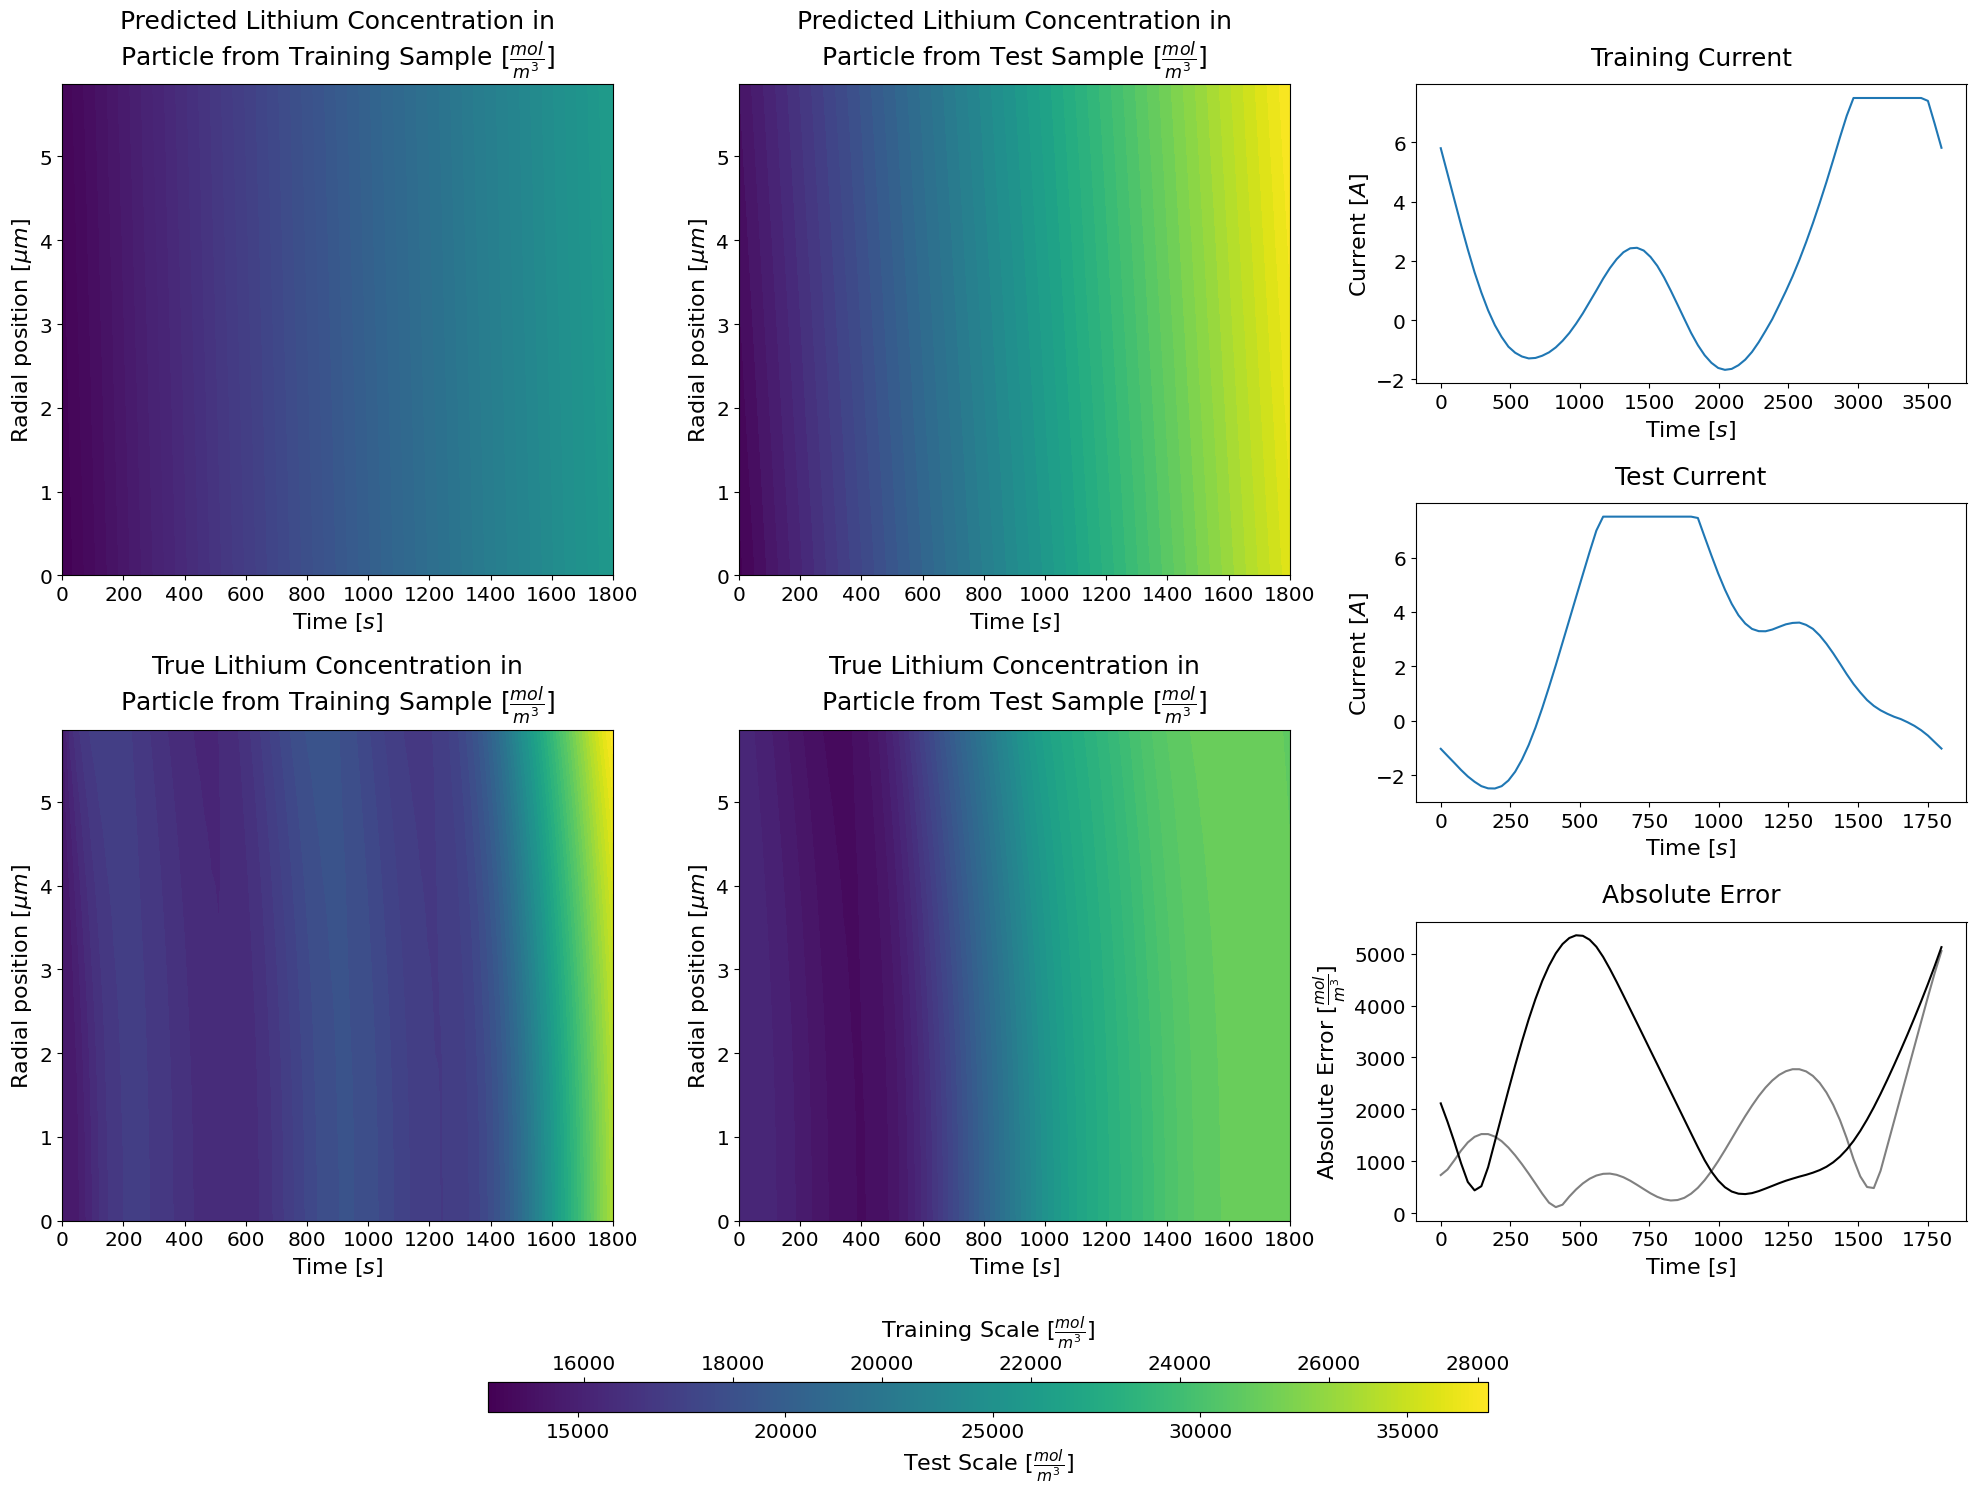

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import jax.numpy as jnp
import numpy as np
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

t_plot = np.linspace(0,1800,75)

T_plot, R_plot = jnp.meshgrid(t_plot, r)

# Extract data for anode and cathode
a_data = np.concatenate([
    c_train_pred_reshaped.ravel(),
    c_train_true_reshaped.ravel()
])
c_data = np.concatenate([
    c_test_pred_reshaped.ravel(),
    c_test_true_reshaped.ravel()
])

a_min, a_max = a_data.min(), a_data.max()
c_min, c_max = c_data.min(), c_data.max()

# Create separate norms for anode and cathode
a_norm = Normalize(vmin=a_min, vmax=a_max)
c_norm = Normalize(vmin=c_min, vmax=c_max)

# Create the figure and main GridSpec
fig = plt.figure(figsize=(20, 15))
gs = gridspec.GridSpec(2, 3, figure=fig)

def rasterize_contour(contour):
    for c in contour.collections:
        c.set_rasterized(True)

# Anode Plots (use a_norm)
ax1 = fig.add_subplot(gs[0,0])
contour1 = ax1.contourf(T_plot, R_plot*Ran*1e6, c_train_pred_reshaped,
                        levels=50, cmap='viridis', norm=a_norm)
# rasterize_contour(contour1)
ax1.set_xlabel('Time [$s$]')
ax1.set_ylabel('Radial position [$µm$]')
ax1.set_title('Predicted Lithium Concentration in\nParticle from Training Sample [$\\frac{mol}{m^3}$]', pad=14)

ax4 = fig.add_subplot(gs[1,0])
contour3 = ax4.contourf(T_plot, R_plot*Ran*1e6, c_train_true_reshaped,
                        levels=50, cmap='viridis', norm=a_norm)
# rasterize_contour(contour3)
ax4.set_xlabel('Time [$s$]')
ax4.set_ylabel('Radial position [$µm$]')
ax4.set_title('True Lithium Concentration in\nParticle from Training Sample [$\\frac{mol}{m^3}$]', pad=14)

# Cathode Plots (use c_norm)
ax2 = fig.add_subplot(gs[0,1])
contour2 = ax2.contourf(T_plot, R_plot*Ran*1e6, c_test_pred_reshaped,
                        levels=50, cmap='viridis', norm=c_norm)
# rasterize_contour(contour2)
ax2.set_xlabel('Time [$s$]')
ax2.set_ylabel('Radial position [$µm$]')
ax2.set_title('Predicted Lithium Concentration in\nParticle from Test Sample [$\\frac{mol}{m^3}$]', pad=14)

ax5 = fig.add_subplot(gs[1,1])
contour4 = ax5.contourf(T_plot, R_plot*Ran*1e6, c_test_true_reshaped,
                        levels=50, cmap='viridis', norm=c_norm)
# rasterize_contour(contour4)
ax5.set_xlabel('Time [$s$]')
ax5.set_ylabel('Radial position [$µm$]')
ax5.set_title('True Lithium Concentration in\nParticle from Test Sample [$\\frac{mol}{m^3}$]', pad=14)

# Right column subdivided into three rows: Current, Voltage, Error
right_gs = gridspec.GridSpecFromSubplotSpec(3, 1, subplot_spec=gs[:, 2], hspace=0.4)

ax_curr = fig.add_subplot(right_gs[0,0])
ax_curr.plot(t, train_I[train_idx])
ax_curr.set_title('Training Current', pad=14)
ax_curr.set_xlabel('Time [$s$]')
ax_curr.set_ylabel('Current [$A$]')

ax_volt = fig.add_subplot(right_gs[1,0])
ax_volt.plot(t_plot, test_I[test_idx], linestyle='-')
#ax_volt.plot(t_plot[:sim_length], V_pred[:sim_length], label='PINN', linestyle='--')
ax_volt.set_title('Test Current', pad=14)
ax_volt.set_xlabel('Time [$s$]')
ax_volt.set_ylabel('Current [$A$]')

ax_err = fig.add_subplot(right_gs[2,0])
ax_err.plot(t_plot, train_error_line, color='grey', label='Training Error', linestyle='-')
ax_err.plot(t_plot, test_error_line, color='black', label='Test Error', linestyle='-')
ax_err.set_title('Absolute Error', pad=14)
ax_err.set_xlabel('Time [$s$]')
ax_err.set_ylabel('Absolute Error [$\\frac{mol}{m^3}$]')

plt.tight_layout(rect=[0,0.125,1,1])  # Leave more space at the bottom for two colorbars

# Create two separate ScalarMappables for the colorbars
sm_anode = ScalarMappable(norm=a_norm, cmap='viridis')
sm_anode.set_array([])
sm_cathode = ScalarMappable(norm=c_norm, cmap='viridis')
sm_cathode.set_array([])

# Add the two colorbars side by side at the bottom
# Adjust positions as needed
cbar_width = 0.5
cbar_height = 0.02
cbar_anode_ax = fig.add_axes([0.25, 0.05, cbar_width, cbar_height])
cbar_cathode_ax = fig.add_axes([0.25, 0.05, cbar_width, cbar_height])

cbar_anode = fig.colorbar(sm_anode, cax=cbar_anode_ax, orientation='horizontal')
cbar_anode.set_label('Training Scale [$\\frac{mol}{m^3}$]', labelpad=12)
cbar_anode.ax.xaxis.set_label_position('top')
cbar_anode.ax.xaxis.set_ticks_position('top')

cbar_cathode = fig.colorbar(sm_cathode, cax=cbar_cathode_ax, orientation='horizontal')
cbar_cathode.set_label('Test Scale [$\\frac{mol}{m^3}$]')

figurename = "2DDONGRFBigPlot" + str(train_idx)
# Save as rasterized SVG with a chosen DPI
#fig.savefig(figurename + "_rasterized.svg", format='svg', transparent=True, dpi=300)
plt.show()

In [ ]:
filename = functions.save_model_params(params, directory = "./trained_models/DON", family = family)

Saved model parameters to ./trained_models/DON/anode_GRF_2025-06-09_20-44-09.msgpack


In [ ]:

id  = "8"
path = "data/spm/DON/"
train_data = np.load(path + "train/" + family  + ".npz")
test_data = np.load(path + "test/" + family  + ".npz")

train_I = np.array(train_data["current"])
test_I = np.array(test_data["current"])

train_cn = np.array(train_data["target_concentration_cathode"])
test_cn = np.array(test_data["target_concentration_cathode"])

train_c0 = np.array(train_data["initial_concentration_cathode"])
test_c0 = np.array(test_data["initial_concentration_cathode"])


cpu = jax.devices("cpu")[0]
gpu = jax.devices("gpu")[0]  # Should be the GPU

In [ ]:
model = DeepONet(branch_layers=branch_layers, trunk_layers=trunk_layers)

# Create dummy inputs
key1, key2 = jax.random.split(jax.random.PRNGKey(0))
dummy_I = jax.random.normal(key1, (num_samples_I,))
dummy_c0 = jax.random.normal(key1, (num_samples_c0,))      # 75 current samples + 10 initial conditions
dummy_trunk_input = jax.random.normal(key2, (num_samples_I*num_samples_c0, 2))   # K=750 points in the (t,r)-space

# Initialize parameters
params = model.init(jax.random.PRNGKey(42), dummy_I, dummy_c0, dummy_trunk_input)

# Forward pass
output = model.apply(params, dummy_I, dummy_c0, dummy_trunk_input)

In [ ]:
train_losses = []
test_losses = []

pbar = trange(num_epochs, desc="Training")

for epoch in pbar:

    # Training phase
    total_train_loss = 0.0
    count = 0

    for I_batch, c0_batch, trunk_pts, cn_batch in data_loader(train_I, train_c0, train_cn, trunk_points, batch_size):
        # targets_flat = cn_batch.reshape(cn_batch.shape[0], -1)
        # loss_value, grads = jax.value_and_grad(loss_fn)(params, I_batch, c0_batch, trunk_pts, targets_flat)
        # updates, opt_state = optimizer.update(grads, opt_state)
        # params = optax.apply_updates(params, updates)

        params, opt_state, loss_value = train_step(params, opt_state, I_batch, c0_batch, trunk_pts, cn_batch)
        
        total_train_loss += loss_value * I_batch.shape[0]
        count += I_batch.shape[0]

    avg_train_loss = total_train_loss / count
    train_losses.append(avg_train_loss)

    # Evaluation on test set after each epoch
    test_targets_flat = test_cn.reshape(test_cn.shape[0], -1)
    test_loss = loss_fn(params, test_I, test_c0, trunk_points, test_targets_flat)
    test_losses.append(test_loss)

    desc_str = f"Epoch {epoch+1}/{num_epochs} | Train Loss: {avg_train_loss:.4f} | Test Loss: {test_loss:.4f}"
    pbar.set_description_str(desc_str)

Epoch 50/50 | Train Loss: 0.0883 | Test Loss: 0.1130: 100%|██████████| 50/50 [00:17<00:00,  2.89it/s]


In [ ]:
filename = functions.save_model_params(params, directory = "./trained_models/DON", family = family, prefix="cathode")

Saved model parameters to ./trained_models/DON/cathode_GRF_2025-06-09_20-44-27.msgpack
